# Estimate average advertising incrementality

## tl;dr

Randomized ad eligibility increased visits by 1.034 percentage points and conversions by 0.115 percentage points in the released benchmark. Both assignment effects are precise, but they do not identify which users benefit most.

## Context & Methods

The primary estimand is the intent-to-treat difference between randomized treatment and control. `exposure` is post-assignment and is excluded from the primary contrast. `scripts/estimate_incrementality.py` creates the saved tables and figures.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
TABLES = PROJECT_ROOT / "results" / "tables"
FIGURES = PROJECT_ROOT / "results" / "figures"

## Results

In [2]:
effects = pd.read_csv(TABLES / "phase2_effect_summary.csv")
columns = ["outcome", "control_rate", "treatment_rate", "absolute_lift", "absolute_ci_lower", "absolute_ci_upper", "relative_lift", "incremental_treated"]
display(effects[columns])

,outcome,control_rate,treatment_rate,absolute_lift,absolute_ci_lower,absolute_ci_upper,relative_lift,incremental_treated
0,visit,0.038201,0.048543,0.010342,0.010056,0.010629,0.270737,122895.208255
1,conversion,0.001938,0.003089,0.001152,0.001085,0.001219,0.594488,13687.310082


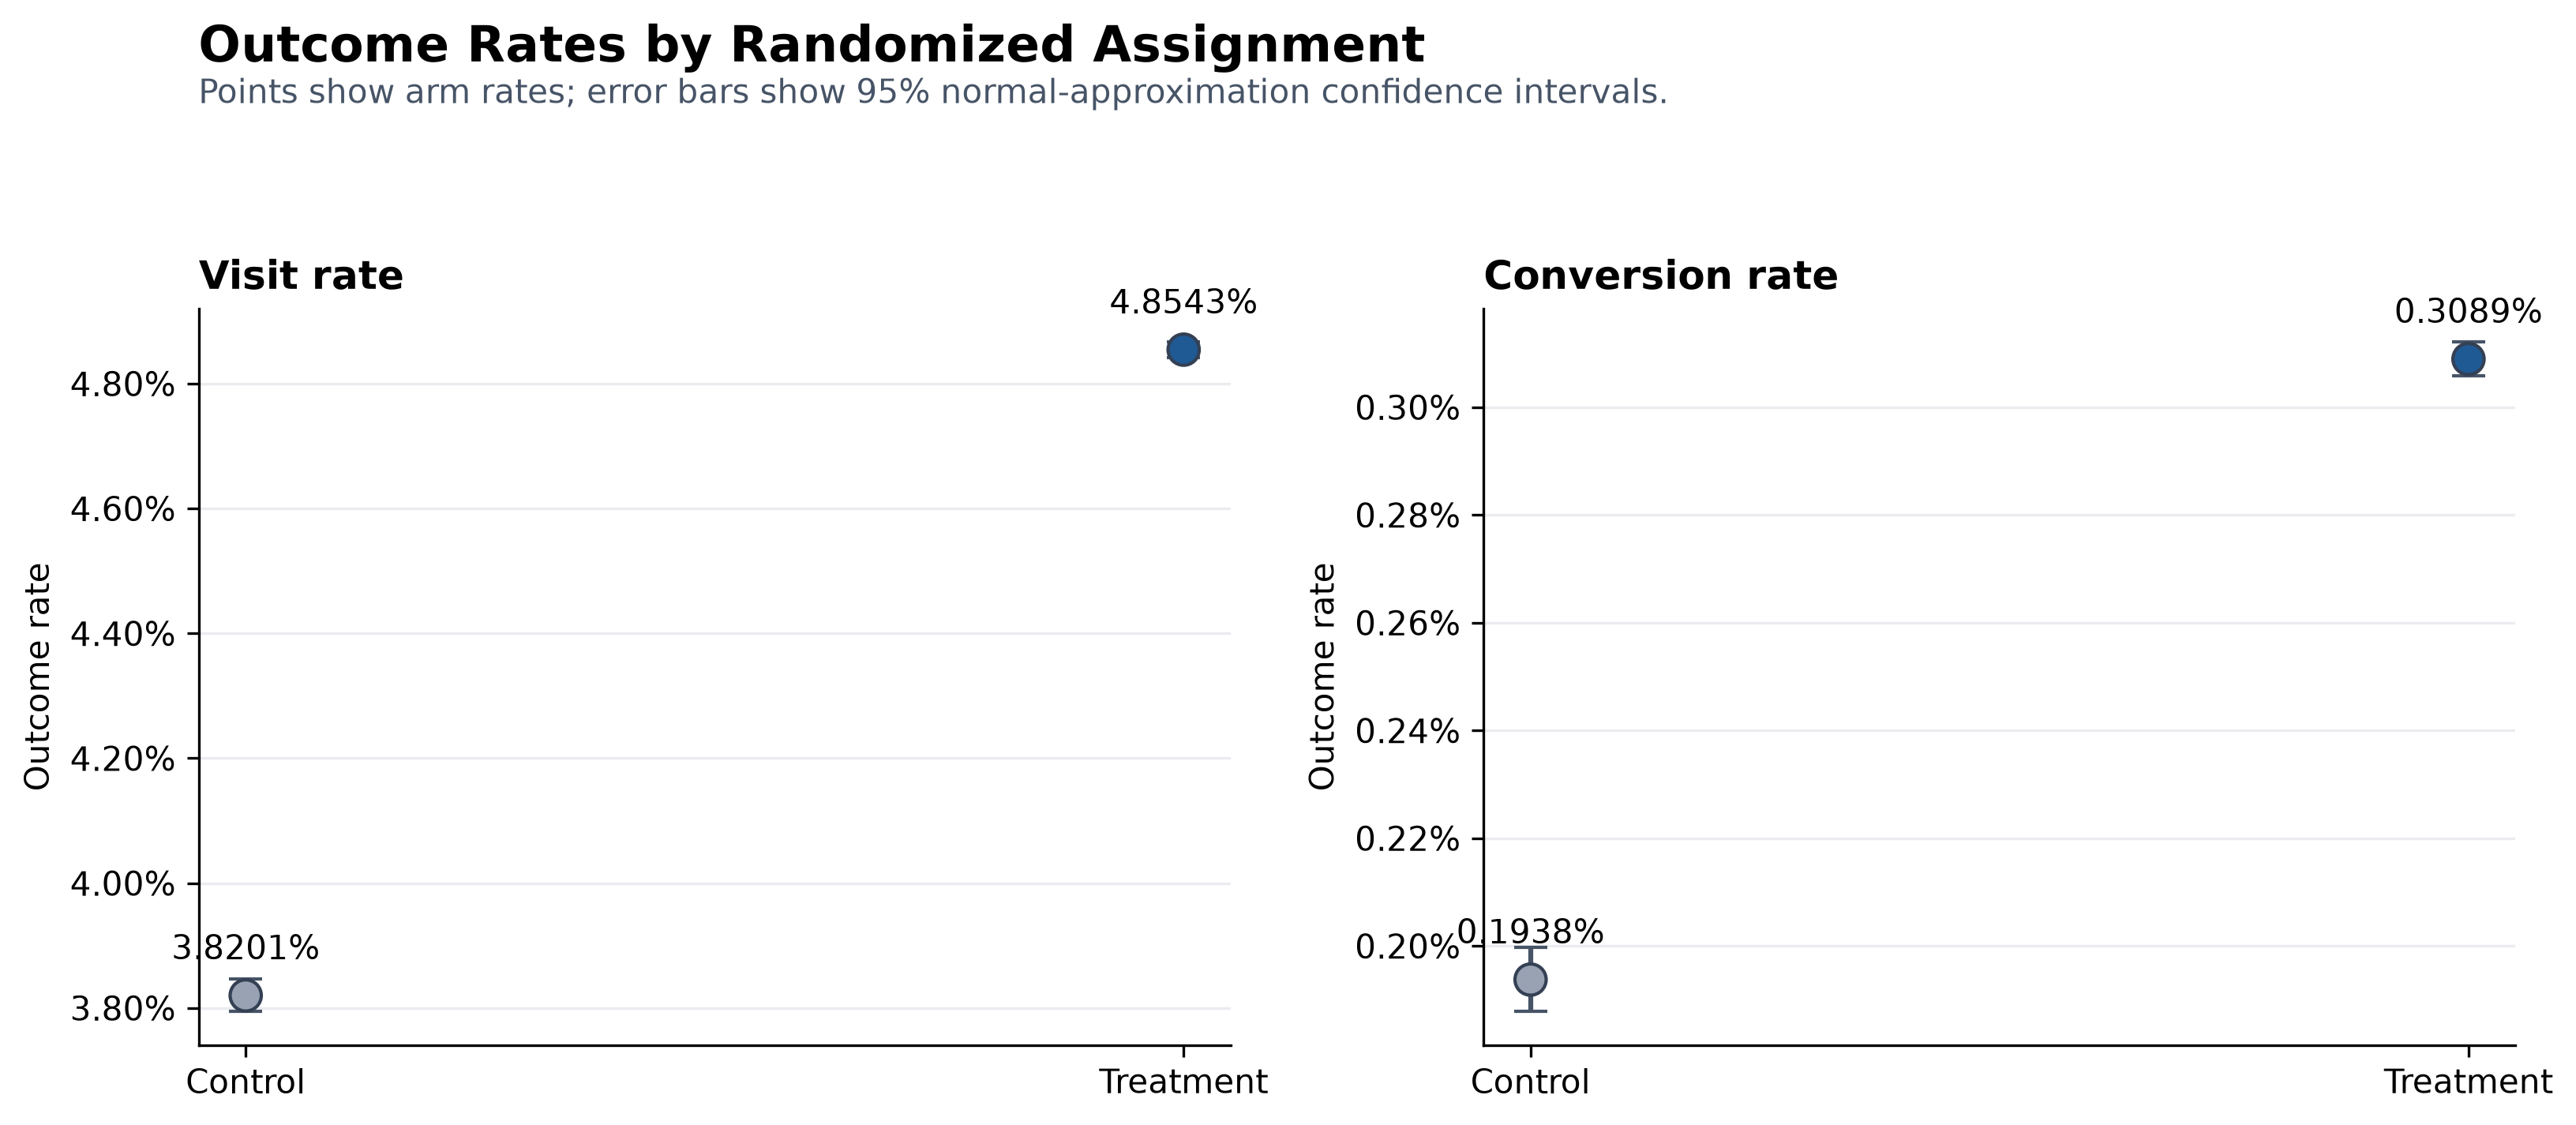

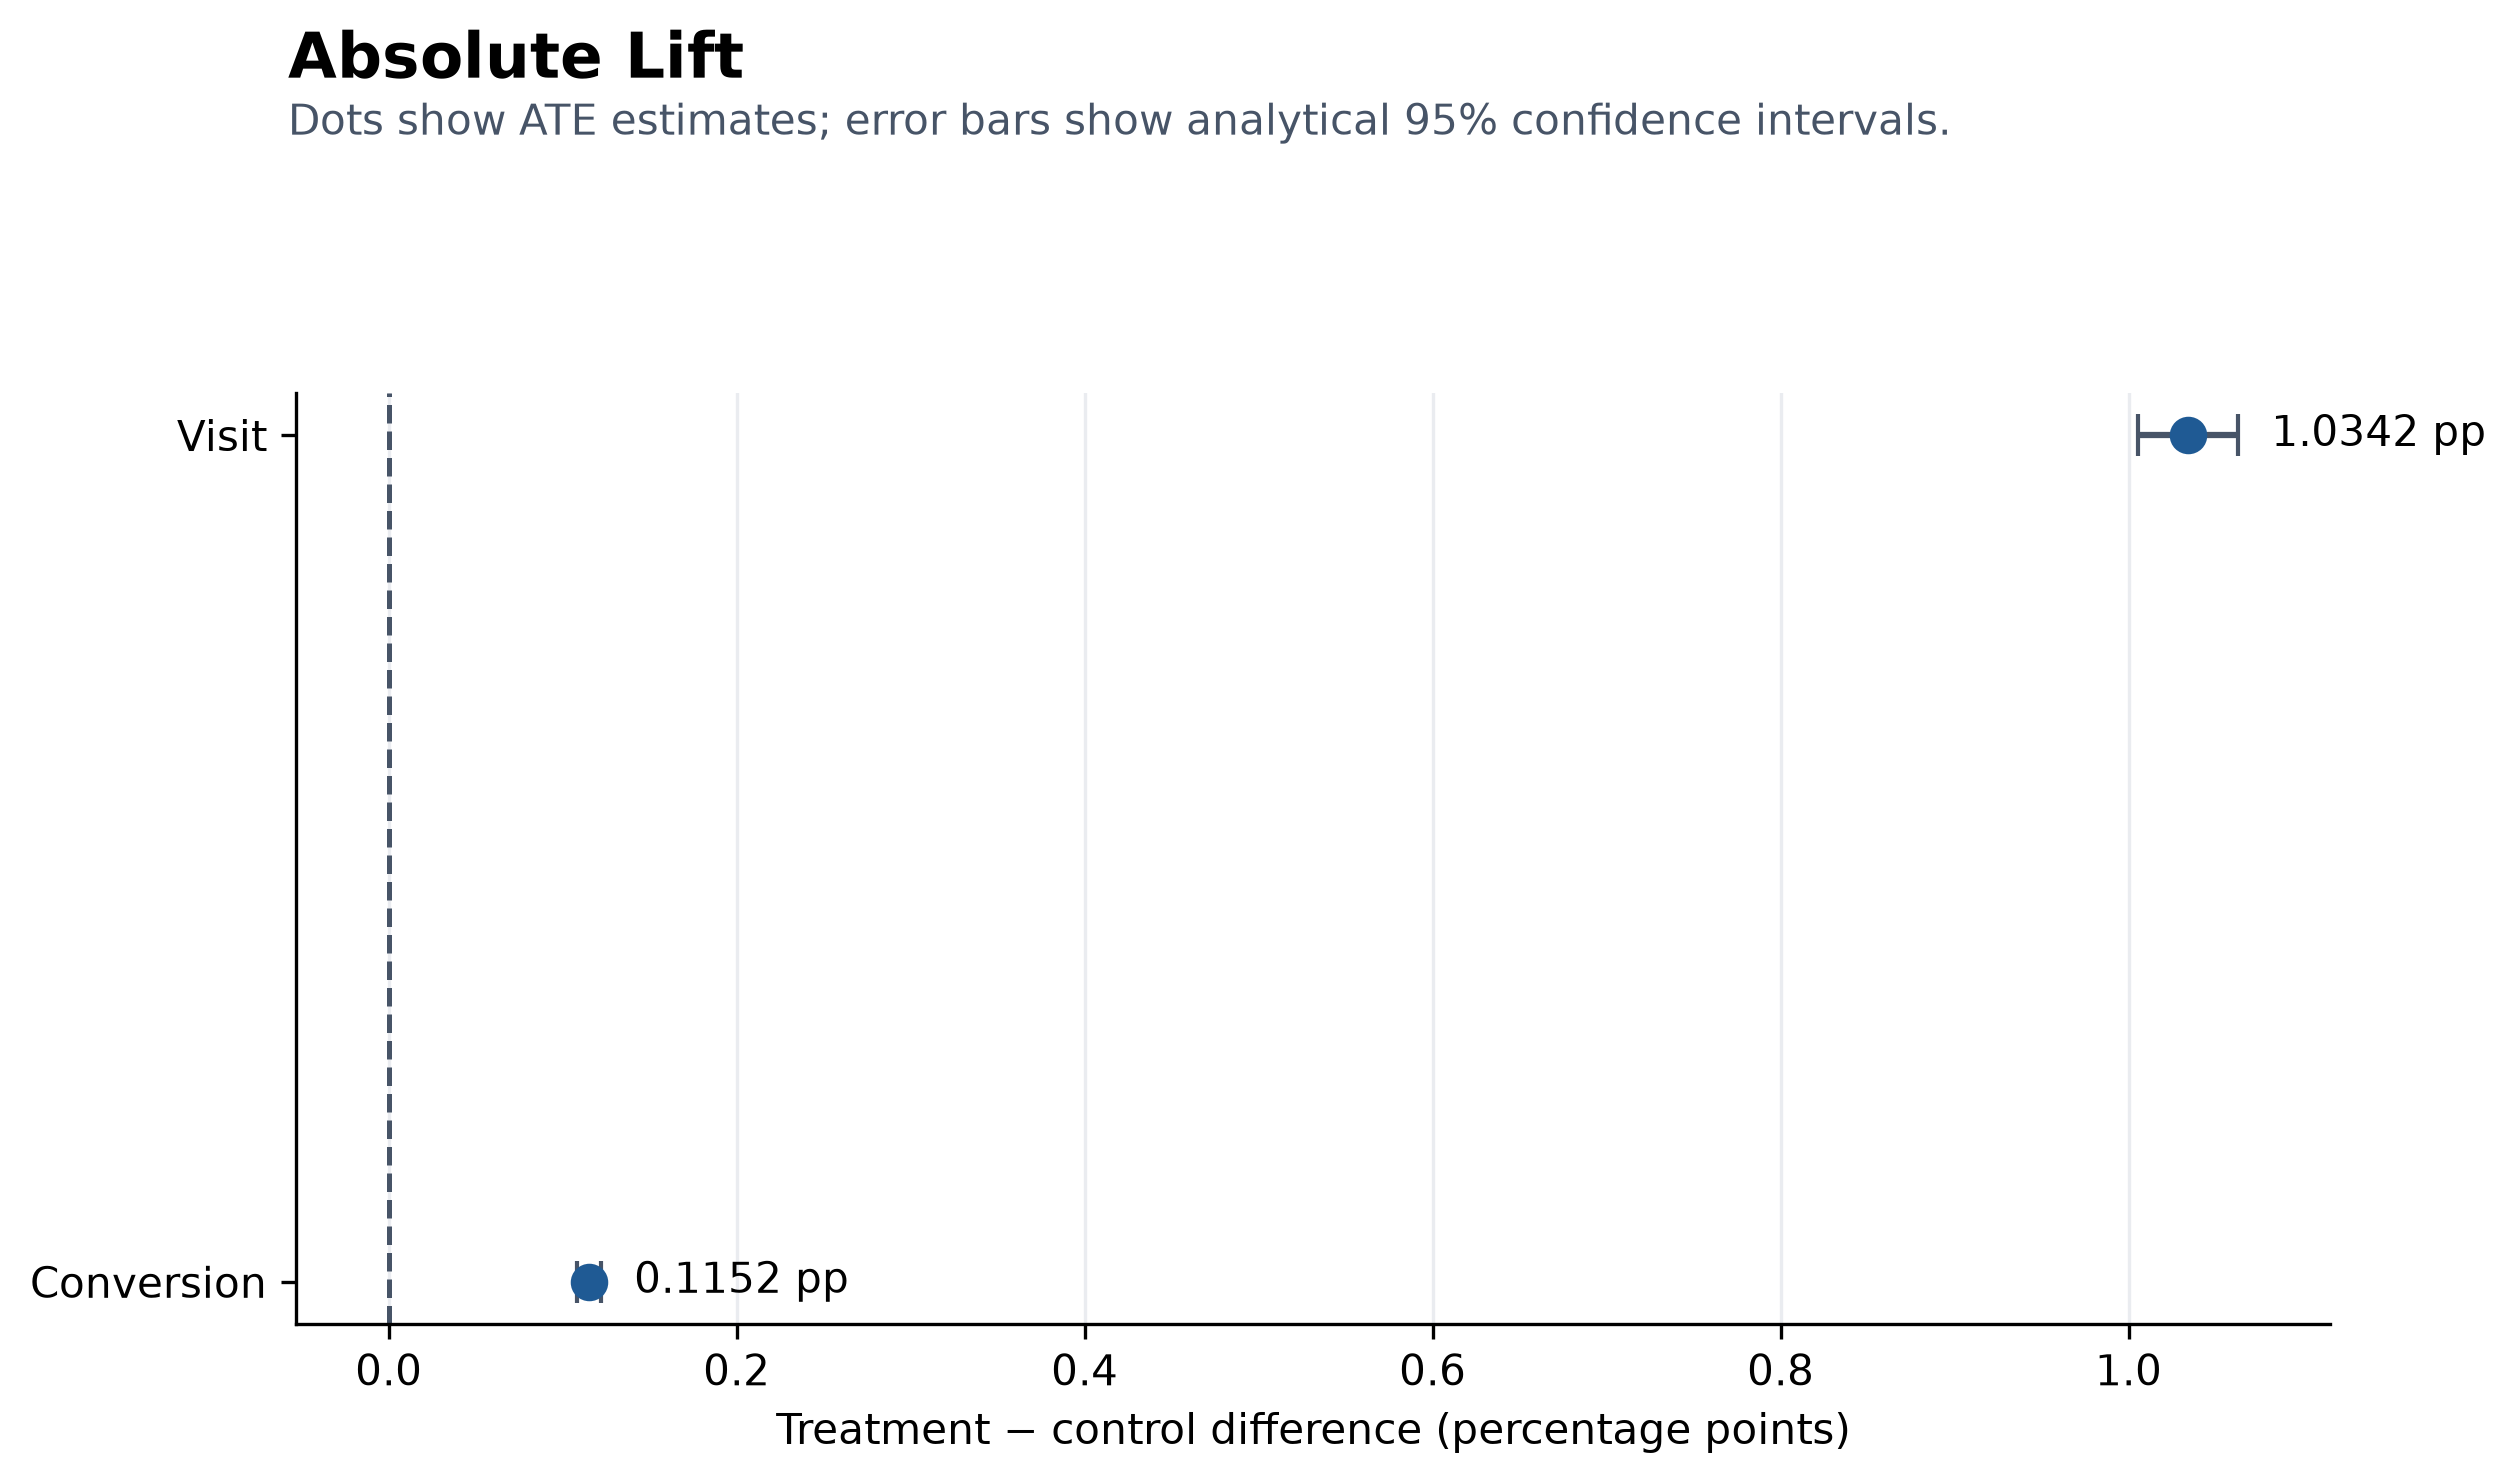

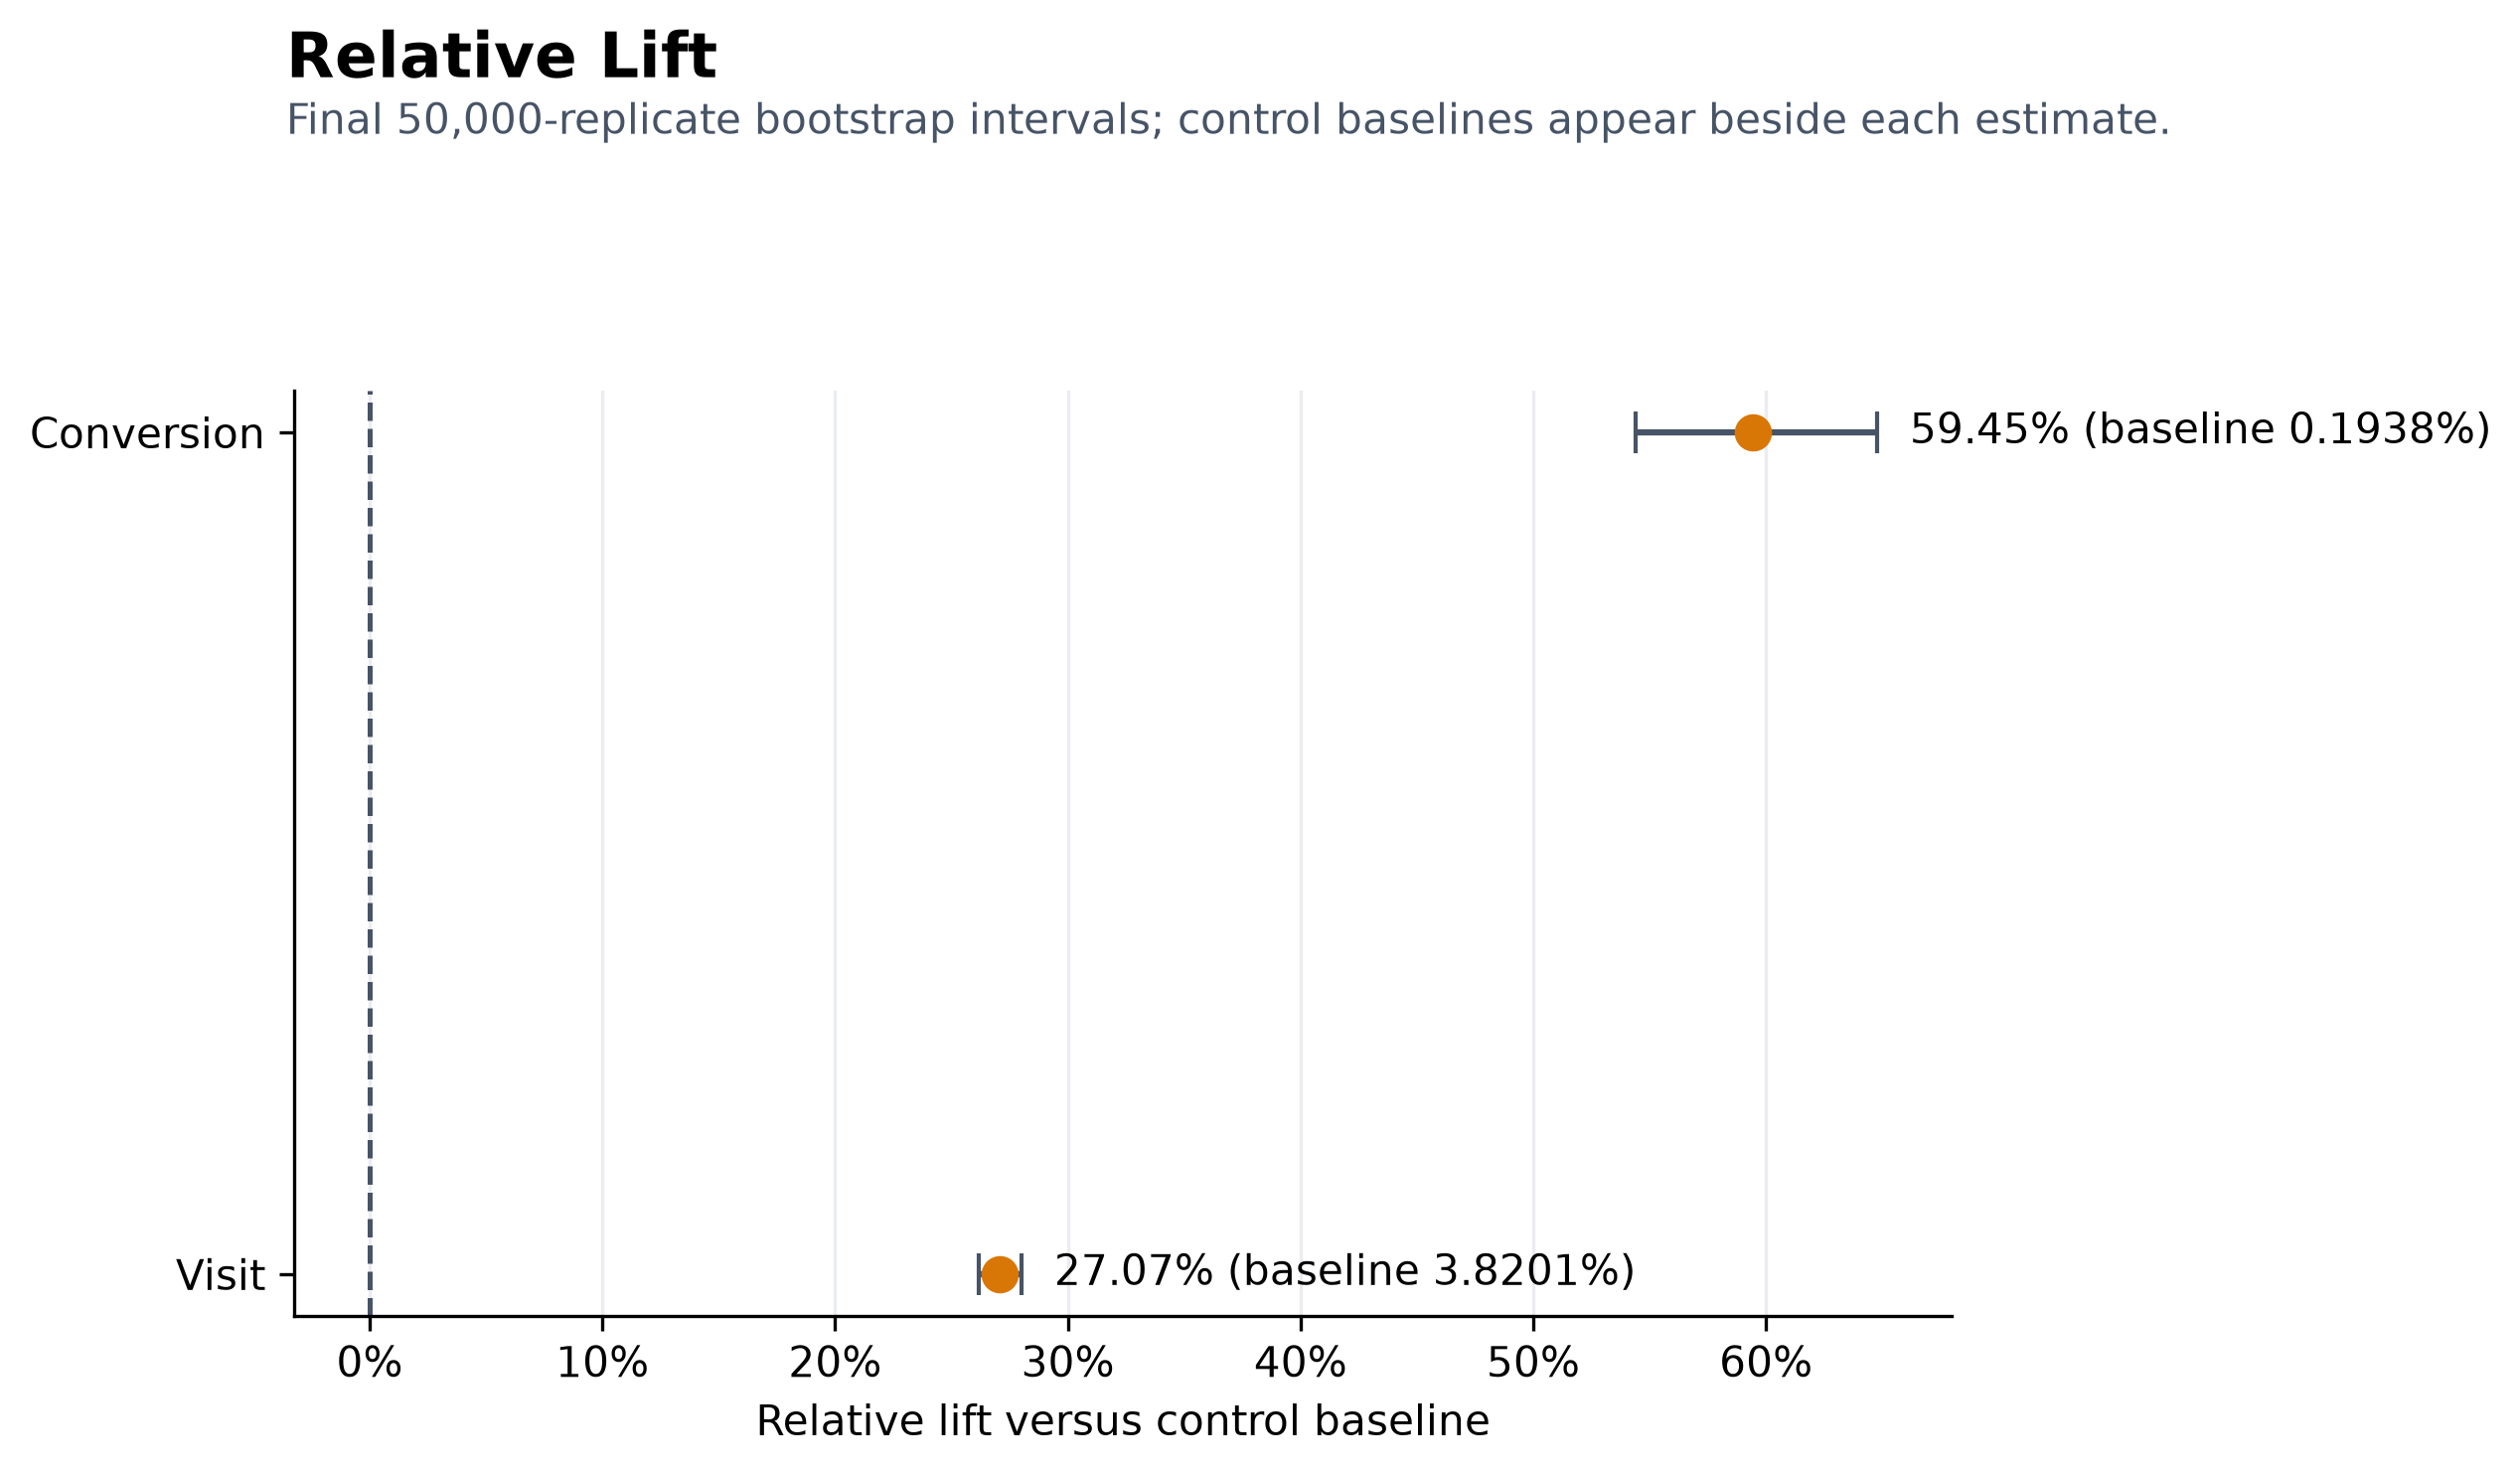

In [3]:
for name in ["arm_rates", "absolute_lift", "relative_lift"]:
    display(Image(filename=FIGURES / f"phase2/{name}.png"))

## Takeaways

The assignment increased both outcomes in this released sample. Multiplying the rate difference by a population produces an estimated aggregate count, not observed individual counterfactuals. The anonymized, non-uniformly subsampled benchmark has no campaign, time, cost, or revenue fields, so these effects do not establish advertiser ROI.